In [2]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from typing import Dict, Any, List
import matplotlib.pyplot as plt

In [3]:
def delta_hedge_transaction(
    data: pd.DataFrame, 
    hedge_frequency: int = 1, 
    transaction_cost_rate: float = 0.000
) -> Dict[str, Any]:

    # Sort time series
    data = data.sort_values(by='date').reset_index(drop=True)
    N = len(data)

    # Initial hedge position
    delta = data.loc[0, 'delta']
    errors = []
    
    # Time loop
    for i in range(1, N):
        C1, C2 = data.loc[i - 1, 'C'], data.loc[i, 'C']
        S1, S2 = data.loc[i - 1, 'S'], data.loc[i, 'S']

        # Basic delta-hedging P&L increment
        A = (C2 - C1) - delta * (S2 - S1)

        # Rebalance at given frequency
        if i % hedge_frequency == 0:
            delta_new = data.loc[i, 'delta']

            # Transaction cost
            trade_size = abs(delta_new - delta)
            cost = transaction_cost_rate * trade_size * S2

            # Deduct cost from hedging P&L
            A -= cost

            # Update delta position
            delta = delta_new

        # Store error and TTM
        errors.append([data.loc[i, 'TTM'], A])

    # Build dataframe of hedging errors
    error_df = pd.DataFrame(errors, columns=['TTM', 'error'])

    # Summary statistics
    result = {
        'expiration_date': data['expiration_date'].iloc[0],
        'K': data['K'].iloc[0],
        'initial_moneyness': data['initial_moneyness'].iloc[0],
        'hedge_frequency': hedge_frequency,
        'transaction_cost_rate': transaction_cost_rate,
        'errors': error_df,
        'mse': np.mean(error_df['error'] ** 2),
        'mean_error': np.mean(error_df['error']),
        'std_error': np.std(error_df['error']),
    }

    return result


In [4]:
def run_delta_hedge_analysis(
    data: pd.DataFrame,
    frequencies: List[int],
    transaction_cost_rate: float = 0.15
) -> pd.DataFrame:

    results = []

    # Loop over moneyness buckets
    for mon in ['ATM', 'ITM', 'OTM']:
        data_mon = data[data['initial_moneyness'] == mon].copy()

        # Loop over hedge frequencies
        for freq in frequencies:

            # Loop over each option ID
            for _, opt_data in data_mon.groupby('option_id'):

                res = delta_hedge_transaction(
                    data=opt_data,
                    hedge_frequency=freq,
                    transaction_cost_rate=transaction_cost_rate
                )

                if res is not None:
                    results.append(res)
                else:
                    print(f"Skipping option_id {opt_data['option_id'].iloc[0]}.")

    # Return results as a summary dataframe
    summary = pd.DataFrame(results)
    return summary

In [5]:
ticker = 'AAPL'
data = pd.read_csv(f"AAPL_processed.csv")

data['date'] = pd.to_datetime(data['date'])
data['expiration_date'] = pd.to_datetime(data['expiration_date'])

In [6]:
per_option = (
    data[['option_id', 'expiration_date', 'initial_moneyness']]
    .drop_duplicates()
)
counts = (
    per_option
    .groupby(['expiration_date', 'initial_moneyness'])
    .size()
    .unstack(fill_value=0)       # columns: ATM / ITM / OTM
    .sort_index()
)
counts['TOTAL'] = counts.sum(axis=1)
counts

initial_moneyness,ATM,ITM,OTM,TOTAL
expiration_date,,,,
2020-09-18,1,0,6,7
2020-10-16,1,3,2,6
2020-11-20,1,0,6,7
2020-12-18,0,0,8,8
2021-01-15,1,2,10,13
2021-02-19,1,0,9,10
2021-03-19,1,2,6,9
2021-04-16,0,0,8,8
2021-05-21,0,0,6,6


In [7]:
first_rows_per_expiration_date = (
    data
    .sort_values('date')
    .groupby('option_id')
    .first()
    .reset_index()
)
mean_delta = first_rows_per_expiration_date.groupby('initial_moneyness')['delta'].mean()
mean_delta

initial_moneyness
ATM    0.512900
ITM    0.771685
OTM    0.115773
Name: delta, dtype: float64

In [8]:
def select_one_option_per_moneyness(data):
    # gives one row per option: | option_id | expiration_date | initial_moneyness | delta_start |
    per_option = (
        data[['option_id', 'expiration_date', 'initial_moneyness', 'delta_start']]
        .drop_duplicates()
    )

    targets = {'ITM': 0.75, 'ATM': 0.50, 'OTM': 0.25}

    selected_rows = []

    # iterate over expiration dates
    for exp, group_exp in per_option.groupby('expiration_date'):

        # for each moneyness bucket
        for mon, target in targets.items():
            group_mon = group_exp[group_exp["initial_moneyness"] == mon]


            # find row with delta_start closest to target
            idx = (group_mon["delta_start"] - target).abs().idxmin()
            selected_rows.append(group_mon.loc[idx])

    selected = pd.DataFrame(selected_rows).reset_index(drop=True)
    return selected



In [9]:
valid_expirations = counts[
    (counts['ATM'] > 0) &
    (counts['ITM'] > 0) &
    (counts['OTM'] > 0)
].index

analysis_data = data[data['expiration_date'].isin(valid_expirations)].copy()

selected = select_one_option_per_moneyness(analysis_data)
selected_ids = selected['option_id']
analysis_data = analysis_data[analysis_data['option_id'].isin(selected_ids)]

In [10]:
frequencies = [1, 2, 3, 7, 8, 9, 10, 15]
moneyness_levels = ['ITM', 'ATM', 'OTM']
summary = run_delta_hedge_analysis(analysis_data, frequencies)
summary.head()

,expiration_date,K,initial_moneyness,hedge_frequency,transaction_cost_rate,errors,mse,mean_error,std_error
0,2020-10-16,135.0,ATM,1,0.15,TTM error 0 0.120548 -0.034954 ...,0.533210,-0.505521,0.526934
1,2021-01-15,125.0,ATM,1,0.15,TTM error 0 0.120548 -0.190026 ...,2.559513,-1.287291,0.949945
2,2021-03-19,135.0,ATM,1,0.15,TTM error 0 0.120548 -0.738895 ...,0.733506,-0.640694,0.568346
3,2022-01-21,170.0,ATM,1,0.15,TTM error 0 0.120548 -1.793436 ...,7.304230,-2.161660,1.622176
4,2022-02-18,180.0,ATM,1,0.15,TTM error 0 0.120548 -2.267468 ...,2.294906,-1.200670,0.923741


In [11]:
aggregated_summary = (
    summary
    .groupby(['hedge_frequency', 'initial_moneyness'])['mse']
    .agg(
        mean_mse='mean',
        std_mse='std',
        n_options='count'
    )
    .reset_index()
)

aggregated_summary['initial_moneyness'] = pd.Categorical(
    aggregated_summary['initial_moneyness'],
    categories=moneyness_levels,
    ordered=True
)

aggregated_summary = aggregated_summary.sort_values([
    'hedge_frequency',
    'initial_moneyness'
])
aggregated_summary.head()

,hedge_frequency,initial_moneyness,mean_mse,std_mse,n_options
1,1,ITM,4.292458,2.550103,10
0,1,ATM,2.996523,2.854930,10
2,1,OTM,1.112855,1.116285,10
4,2,ITM,4.194405,2.673124,10
3,2,ATM,3.644421,3.982372,10


In [12]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
# axes = axes.ravel()

# for idx, freq in enumerate(frequencies):
#     ax = axes[idx]

#     df = aggregated_summary[aggregated_summary['hedge_frequency'] == freq]

#     x = np.arange(len(df))
#     means = df['mean_mse'].values
#     stds = df['std_mse'].values
#     labels = df['initial_moneyness'].astype(str).tolist()

#     # ax.bar(x, means, yerr=stds)
#     ax.bar(x, means)
#     ax.set_xticks(x)
#     ax.set_xticklabels(labels)

#     ax.set_title(f"Hedge frequency [days] = {freq}")
#     ax.grid(axis="y", alpha=0.3)
#     if idx % 2 == 0:
#         ax.set_ylabel("Mean MSE")

# for ax in axes[-2:]:
#     ax.set_xlabel("Initial moneyness")

# fig.suptitle("Mean MSE vs Moneyness for Different Hedging Frequencies", fontsize=14)
# fig.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

In [13]:
aggregated_freq = (
    summary
    .groupby('hedge_frequency')['mse']
    .agg(
        mean_mse="mean",
        std_mse="std",
        n_options="count"
    )
    .reset_index()
    .sort_values("hedge_frequency")
)
aggregated_freq

,hedge_frequency,mean_mse,std_mse,n_options
0,1,2.800612,2.587921,30
1,2,3.012050,3.052293,30
2,3,2.622394,2.819197,30
3,7,1.853855,1.501832,30
4,8,2.123045,1.630663,30
5,9,2.313851,1.467636,30
6,10,2.851323,2.398042,30
7,15,3.011790,2.704277,30


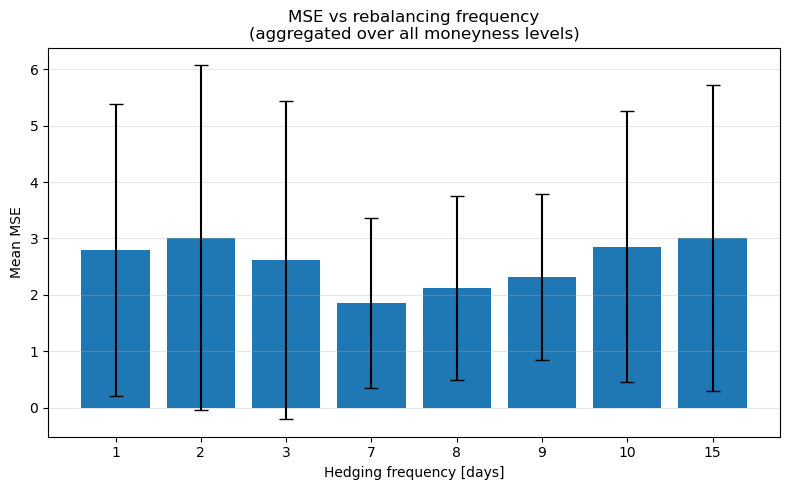

In [14]:
plt.figure(figsize=(8, 5))

x = np.arange(len(aggregated_freq))
means = aggregated_freq["mean_mse"].values
stds = aggregated_freq["std_mse"].values
labels = aggregated_freq["hedge_frequency"].astype(str).tolist()

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, labels)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

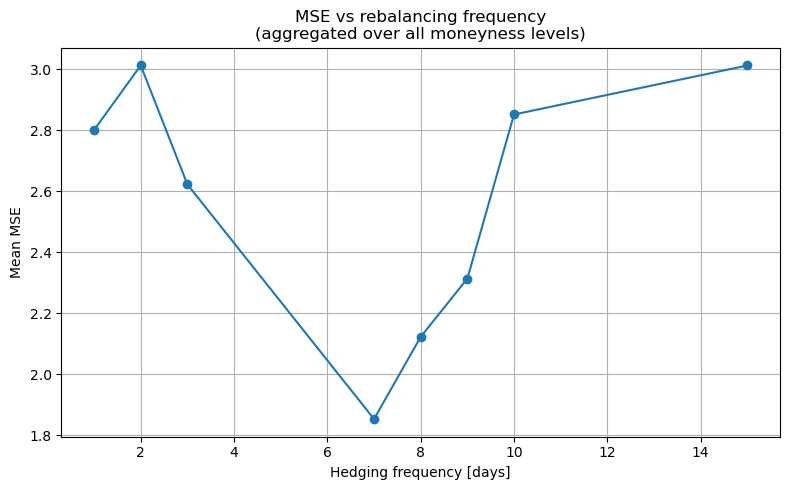

In [15]:
# for showing monotonicity
plt.figure(figsize=(8, 5))

plt.errorbar(
    aggregated_freq["hedge_frequency"],
    aggregated_freq["mean_mse"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(True)
plt.tight_layout()
plt.savefig("deltahedge_transaction.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
aggregated_summary.head()

,hedge_frequency,initial_moneyness,mean_mse,std_mse,n_options
1,1,ITM,4.292458,2.550103,10
0,1,ATM,2.996523,2.854930,10
2,1,OTM,1.112855,1.116285,10
4,2,ITM,4.194405,2.673124,10
3,2,ATM,3.644421,3.982372,10


In [17]:
pivot_mse = aggregated_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='mean_mse'
)

pivot_std = aggregated_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='std_mse'
)
pivot_mse


hedge_frequency,1,2,3,7,8,9,10,15
initial_moneyness,,,,,,,,
ITM,4.292458,4.194405,3.861914,2.759482,2.760547,2.544498,3.505328,3.582573
ATM,2.996523,3.644421,2.921387,1.943647,2.435118,2.577456,3.451525,3.994505
OTM,1.112855,1.197322,1.083882,0.858435,1.173470,1.819599,1.597117,1.458290


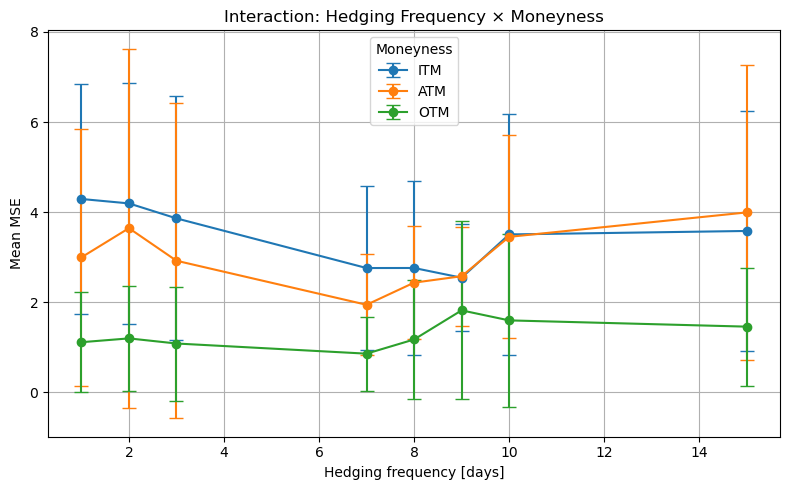

In [18]:
plt.figure(figsize=(8, 5))

for mon in moneyness_levels:
    df_mon = aggregated_summary[aggregated_summary["initial_moneyness"] == mon]
    plt.errorbar(
        df_mon["hedge_frequency"],
        df_mon["mean_mse"],
        yerr=df_mon["std_mse"],
        capsize=5,
        marker="o",
        label=mon
    )

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("Interaction: Hedging Frequency × Moneyness")
plt.legend(title="Moneyness")
plt.grid(True)
plt.tight_layout()
plt.savefig("deltahedge_mse_plot.png", dpi=300, bbox_inches="tight")
plt.show()